## Task 2: Data Pre-processing, Data Analysis and Visualization

This notebook will perform data pre-processing, data analysis, and visualization steps using Python, mimicking the workflow described for the Orange data mining tool.

### Step 1: Load the Dataset

First, we'll load a common dataset for demonstration purposes. The Titanic dataset is often used for these types of tasks. We'll use pandas to load the data from a URL.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
try:
    df = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"Error loading dataset: {e}")
    df = pd.DataFrame() # Create an empty DataFrame if loading fails

# Display the first 5 rows of the dataset
if not df.empty:
    display(df.head())
else:
    print("DataFrame is empty. Please check the dataset loading step.")

Dataset loaded successfully.


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


### Step 2: Initial Data Inspection (Mimicking 'Data Table' widget)

We'll inspect the dataset's information and basic statistics to understand its structure, data types, and identify potential missing values.

In [2]:
if not df.empty:
    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))

    print("\nMissing Values:")
    display(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("DataFrame is empty, skipping initial inspection.")


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB

Descriptive Statistics:


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887,887,887.000000,887.000000,887.000000,887.00000
unique,NaN,NaN,887,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Mr. Patrick Dooley,male,NaN,NaN,NaN,NaN
freq,NaN,NaN,1,573,NaN,NaN,NaN,NaN
mean,0.385569,2.305524,NaN,NaN,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,NaN,NaN,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,NaN,NaN,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,31.13750



Missing Values:


,0


### Step 3: Data Pre-processing (Handling Missing Values and Outliers)

Based on the inspection, we'll address missing values. For numerical columns like 'Age', we might fill missing values with the median. For categorical columns, we might fill with the mode or a placeholder. For 'Cabin', if many values are missing, it might be dropped or a new 'HasCabin' feature created.

For simplicity, we'll fill 'Age' with its median and 'Embarked' with its mode. We'll also drop 'Cabin' due to many missing values and 'Name' as it's not useful for modeling.


In [3]:
if not df.empty:
    # Fill missing 'Age' values with the median
    if 'Age' in df.columns:
        df['Age'].fillna(df['Age'].median(), inplace=True)

    # Fill missing 'Embarked' values with the mode
    if 'Embarked' in df.columns:
        df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

    # Drop 'Cabin' due to a high number of missing values and 'Name' column
    df.drop(columns=['Cabin', 'Name'], inplace=True, errors='ignore')

    print("\nMissing values after preprocessing:")
    display(df.isnull().sum()[df.isnull().sum() > 0])

    print("\nDataFrame after preprocessing (first 5 rows):")
    display(df.head())
else:
    print("DataFrame is empty, skipping data preprocessing.")


Missing values after preprocessing:


/tmp/ipykernel_662/3416510770.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


,0



DataFrame after preprocessing (first 5 rows):


,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


### Step 4: Encode Categorical Variables (Mimicking 'Edit Domain' widget)

We'll identify categorical variables and convert them into numerical format using one-hot encoding, which is suitable for many machine learning models. Columns like 'Sex' and 'Embarked' are good candidates.

In [4]:
if not df.empty:
    # Identify categorical columns to encode (excluding 'Survived' which is the target)
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    print(f"Categorical columns to encode: {categorical_cols}")

    # Apply one-hot encoding
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    print("\nDataFrame after one-hot encoding (first 5 rows):")
    display(df_encoded.head())
    print(f"New shape: {df_encoded.shape}")
else:
    print("DataFrame is empty, skipping categorical encoding.")

Categorical columns to encode: ['Sex']

DataFrame after one-hot encoding (first 5 rows):


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Sex_male
0,0,3,22.0,1,0,7.2500,True
1,1,1,38.0,1,0,71.2833,False
2,1,3,26.0,0,0,7.9250,False
3,1,1,35.0,1,0,53.1000,False
4,0,3,35.0,0,0,8.0500,True


New shape: (887, 7)


### Step 5: Data Analysis (Basic Statistics and Demographics)

Now with a cleaner dataset, we can perform more focused data analysis to understand basic statistics and demographics. This includes examining the distribution of 'Survived' or checking statistics for different groups.

In [5]:
if not df_encoded.empty:
    print("\nSurvival rate:")
    display(df_encoded['Survived'].value_counts(normalize=True))

    print("\nAverage age by survival status:")
    display(df_encoded.groupby('Survived')['Age'].mean())

    print("\nAverage fare by survival status:")
    display(df_encoded.groupby('Survived')['Fare'].mean())

    # You can explore other aggregations as needed
else:
    print("Encoded DataFrame is empty, skipping data analysis.")


Survival rate:


,proportion
Survived,
0,0.614431
1,0.385569



Average age by survival status:


,Age
Survived,
0,30.138532
1,28.408392



Average fare by survival status:


,Fare
Survived,
0,22.208584
1,48.395408


### Step 6: Data Visualization (Mimicking 'Distributions' and 'Scatter Plot' widgets)

We'll use `matplotlib` and `seaborn` to visualize data distributions and relationships between variables. This helps in identifying patterns and anomalies.

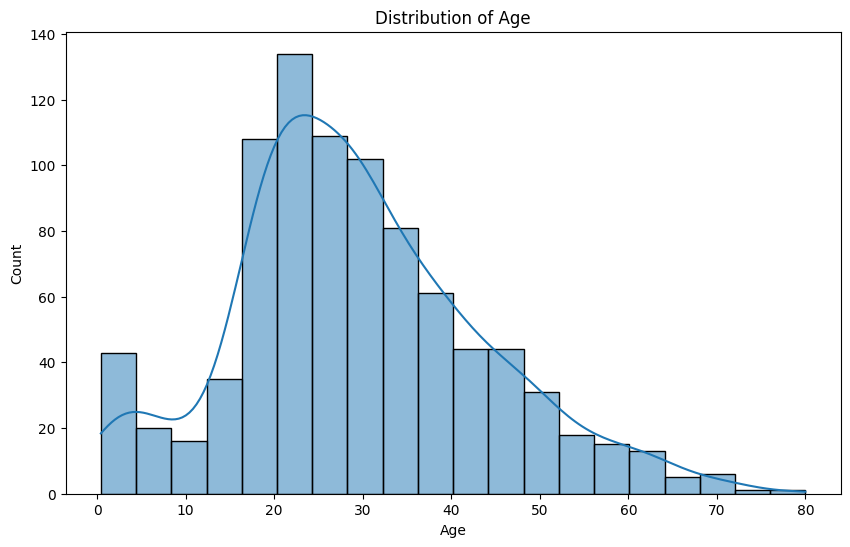

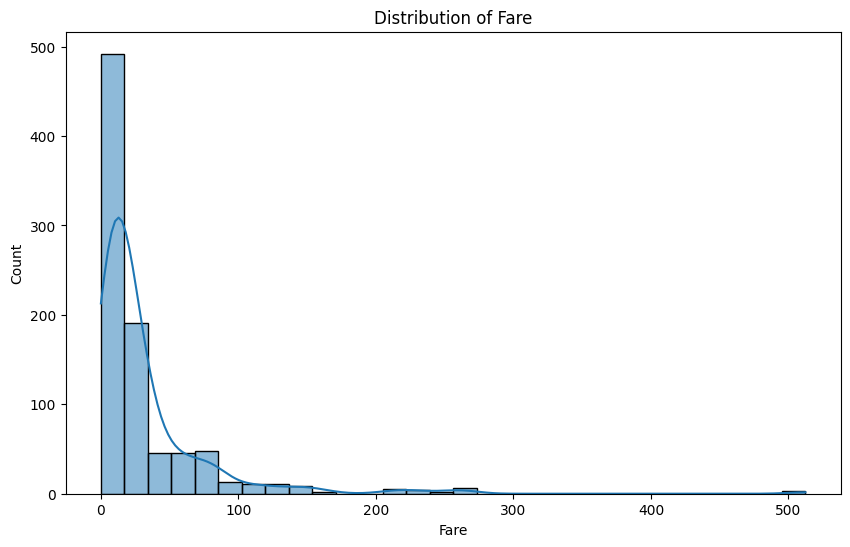

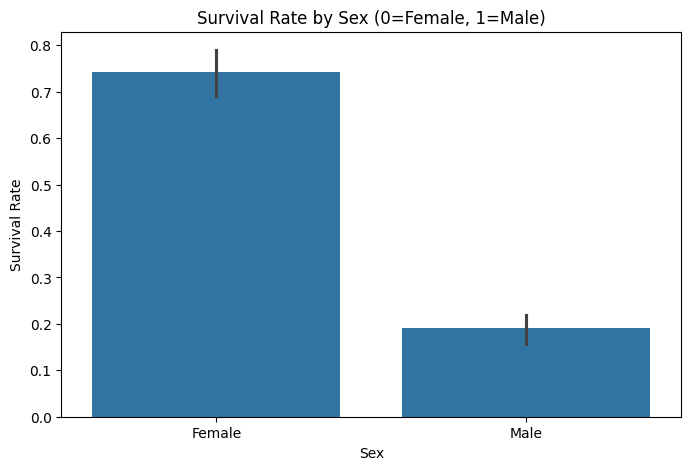

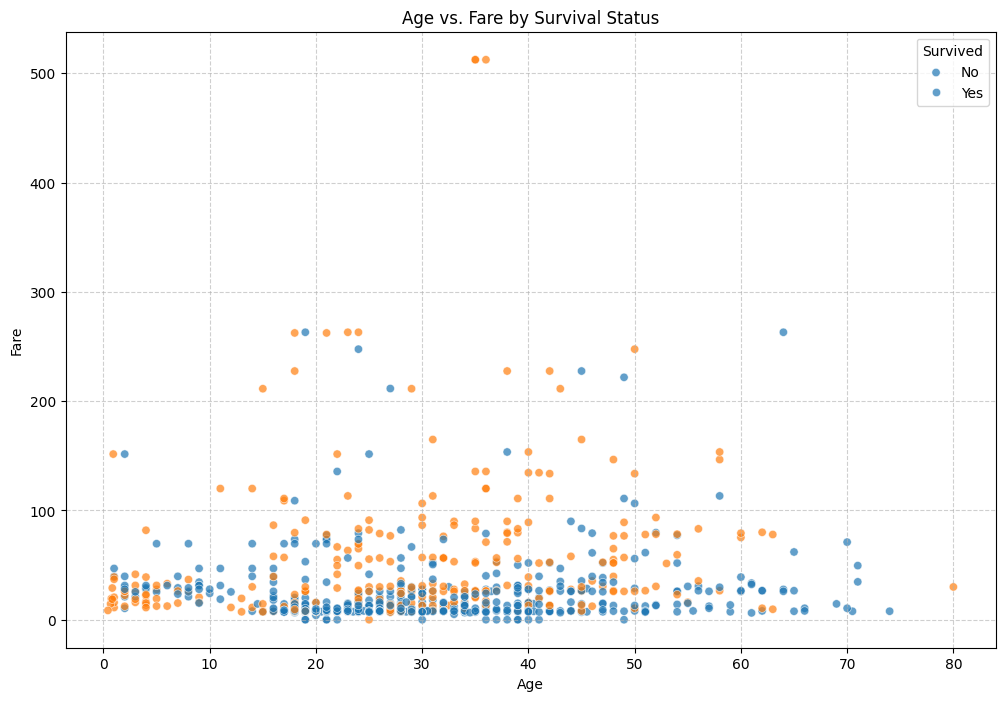

In [6]:
if not df_encoded.empty:
    # Histogram for Age distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df_encoded['Age'], bins=20, kde=True)
    plt.title('Distribution of Age')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.show()

    # Histogram for Fare distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df_encoded['Fare'], bins=30, kde=True)
    plt.title('Distribution of Fare')
    plt.xlabel('Fare')
    plt.ylabel('Count')
    plt.show()

    # Bar plot for survival rate by Sex
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Sex_male', y='Survived', data=df_encoded)
    plt.title('Survival Rate by Sex (0=Female, 1=Male)')
    plt.xlabel('Sex')
    plt.ylabel('Survival Rate')
    plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
    plt.show()

    # Scatter plot for Age vs. Fare, colored by Survival Status
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_encoded, alpha=0.7)
    plt.title('Age vs. Fare by Survival Status')
    plt.xlabel('Age')
    plt.ylabel('Fare')
    plt.legend(title='Survived', loc='upper right', labels=['No', 'Yes'])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Encoded DataFrame is empty, skipping data visualization.")